In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset"
)

CHECKPOINT_ROOT = (
    PROJECT_ROOT
    / "shared_backbone_workspace"
    / "checkpoints"
    / "full_hybrid_person_roi"
)

EVALUATION_ROOT = (
    CHECKPOINT_ROOT
    / "evaluation"
)

HELMET_EXPERIMENT_ROOT = (
    CHECKPOINT_ROOT
    / "helmet_mask_guided"
)

TRAINING_HISTORY_PATH = (
    CHECKPOINT_ROOT
    / "training_history.csv"
)

TEST_CLASS_METRICS_PATH = (
    EVALUATION_ROOT
    / "test_class_metrics.csv"
)

HELMET_HISTORY_PATH = (
    HELMET_EXPERIMENT_ROOT
    / "helmet_training_history.csv"
)

BEST_MODEL_PATH = (
    CHECKPOINT_ROOT
    / "best_loss_model.pt"
)

paths = {
    "전체 학습 기록": TRAINING_HISTORY_PATH,
    "클래스별 테스트 결과": TEST_CLASS_METRICS_PATH,
    "안전모 개선 실험 기록": HELMET_HISTORY_PATH,
    "최종 모델": BEST_MODEL_PATH,
}

for name, path in paths.items():
    print(
        f"{name}:",
        "존재" if path.exists() else "없음",
        path,
    )

전체 학습 기록: 존재 /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/full_hybrid_person_roi/training_history.csv
클래스별 테스트 결과: 존재 /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/full_hybrid_person_roi/evaluation/test_class_metrics.csv
안전모 개선 실험 기록: 존재 /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/full_hybrid_person_roi/helmet_mask_guided/helmet_training_history.csv
최종 모델: 존재 /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/full_hybrid_person_roi/best_loss_model.pt


In [4]:
training_history_df = pd.read_csv(
    TRAINING_HISTORY_PATH
)

display(
    training_history_df.round(4)
)

,epoch,learning_rate,train_loss,train_seg_loss,train_cls_loss,train_dice,train_iou,train_accuracy,val_loss,val_seg_loss,val_cls_loss,val_dice,val_iou,val_accuracy,epoch_seconds
0,1,0.0001,0.1025,0.0886,0.0139,0.8815,0.8097,0.9955,0.3579,0.1010,0.2569,0.8575,0.7740,0.9182,3504.7168
1,2,0.0001,0.0550,0.0539,0.0010,0.9254,0.8681,0.9999,0.4709,0.0927,0.3782,0.8728,0.7935,0.8338,460.9991
2,3,0.0000,0.0510,0.0494,0.0016,0.9313,0.8775,0.9996,1.0682,0.1090,0.9592,0.8517,0.7618,0.8574,455.7656
3,4,0.0000,0.0434,0.0432,0.0002,0.9397,0.8907,1.0000,0.3555,0.0848,0.2706,0.8842,0.8110,0.9188,453.1629
4,5,0.0000,0.0401,0.0400,0.0000,0.9439,0.8975,1.0000,0.6511,0.0871,0.5640,0.8817,0.8066,0.8688,460.1036
5,6,0.0000,0.0384,0.0384,0.0000,0.9461,0.9012,1.0000,0.4224,0.0851,0.3374,0.8849,0.8117,0.8943,452.9164
6,7,0.0000,0.0356,0.0356,0.0000,0.9499,0.9074,1.0000,0.5858,0.0881,0.4977,0.8823,0.8057,0.8761,455.9411
7,8,0.0000,0.0345,0.0345,0.0000,0.9514,0.9099,1.0000,0.5348,0.0863,0.4485,0.8844,0.8100,0.8777,452.7694


In [5]:
best_loss_row = training_history_df.loc[
    training_history_df["val_loss"].idxmin()
]

best_dice_row = training_history_df.loc[
    training_history_df["val_dice"].idxmax()
]

training_summary_df = pd.DataFrame([
    {
        "선정 기준": "최저 Validation Loss",
        "Epoch": int(best_loss_row["epoch"]),
        "Val Loss": best_loss_row["val_loss"],
        "Val Dice": best_loss_row["val_dice"],
        "Val IoU": best_loss_row["val_iou"],
        "Val Accuracy": best_loss_row["val_accuracy"],
    },
    {
        "선정 기준": "최고 Validation Dice",
        "Epoch": int(best_dice_row["epoch"]),
        "Val Loss": best_dice_row["val_loss"],
        "Val Dice": best_dice_row["val_dice"],
        "Val IoU": best_dice_row["val_iou"],
        "Val Accuracy": best_dice_row["val_accuracy"],
    },
])

display(
    training_summary_df.round(4)
)

,선정 기준,Epoch,Val Loss,Val Dice,Val IoU,Val Accuracy
0,최저 Validation Loss,4,0.3555,0.8842,0.8110,0.9188
1,최고 Validation Dice,6,0.4224,0.8849,0.8117,0.8943


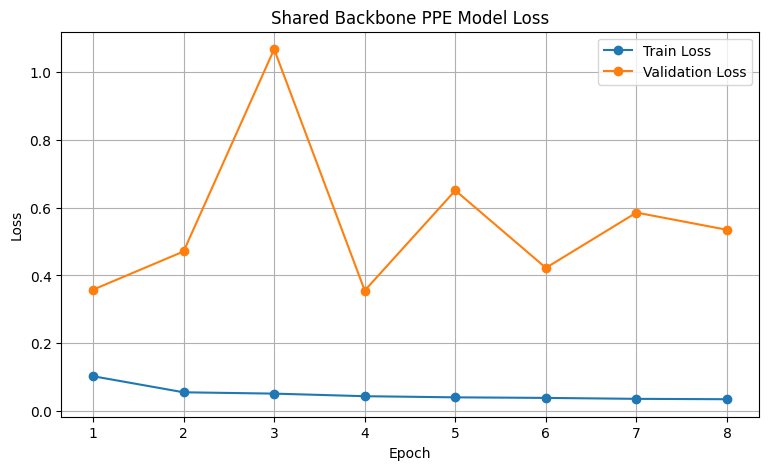

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_history_df["epoch"],
    training_history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    training_history_df["epoch"],
    training_history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Shared Backbone PPE Model Loss")
plt.xticks(training_history_df["epoch"])
plt.grid(True)
plt.legend()
plt.show()

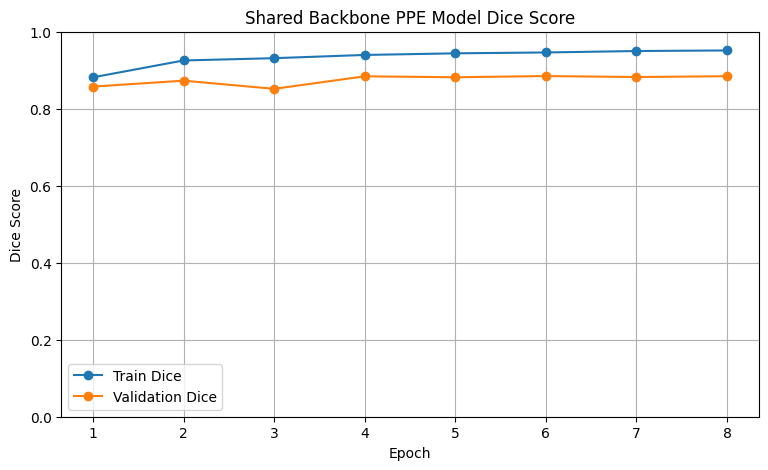

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_history_df["epoch"],
    training_history_df["train_dice"],
    marker="o",
    label="Train Dice",
)

plt.plot(
    training_history_df["epoch"],
    training_history_df["val_dice"],
    marker="o",
    label="Validation Dice",
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Shared Backbone PPE Model Dice Score")
plt.xticks(training_history_df["epoch"])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

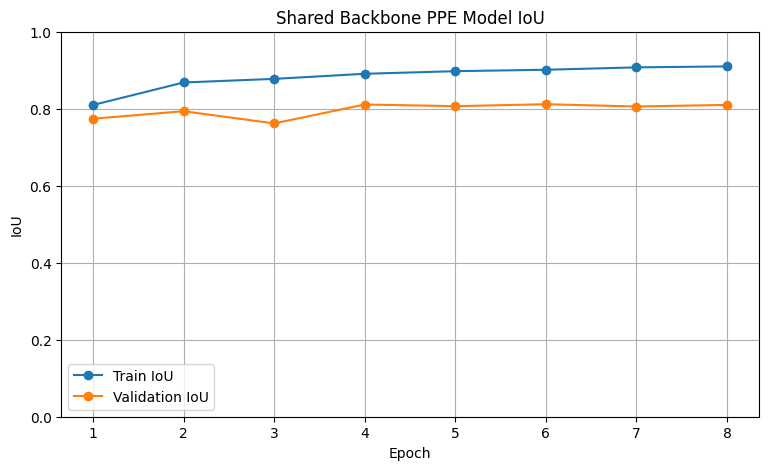

In [8]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_history_df["epoch"],
    training_history_df["train_iou"],
    marker="o",
    label="Train IoU",
)

plt.plot(
    training_history_df["epoch"],
    training_history_df["val_iou"],
    marker="o",
    label="Validation IoU",
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Shared Backbone PPE Model IoU")
plt.xticks(training_history_df["epoch"])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

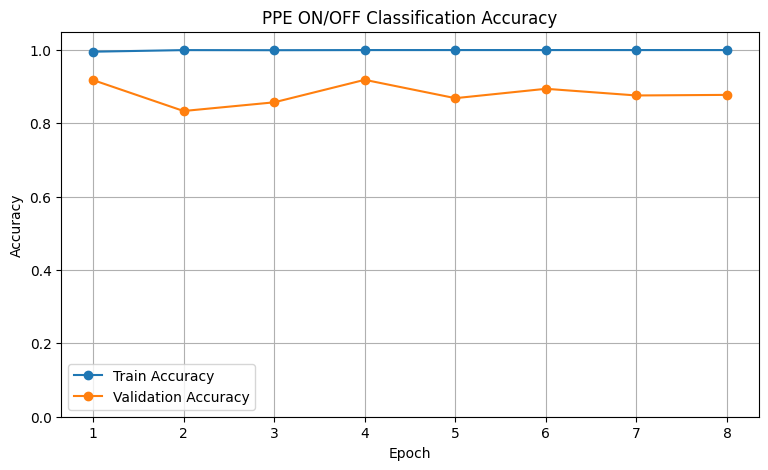

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_history_df["epoch"],
    training_history_df["train_accuracy"],
    marker="o",
    label="Train Accuracy",
)

plt.plot(
    training_history_df["epoch"],
    training_history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PPE ON/OFF Classification Accuracy")
plt.xticks(training_history_df["epoch"])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [10]:
checkpoint_test_results_df = pd.DataFrame([
    {
        "Checkpoint": "best_loss_model.pt",
        "Epoch": 4,
        "Test Loss": 0.1650,
        "Test Seg Loss": 0.0940,
        "Test Cls Loss": 0.0709,
        "Test Dice": 0.8691,
        "Test IoU": 0.7929,
        "Test Accuracy": 0.9701,
        "최종 채택": "채택",
    },
    {
        "Checkpoint": "best_dice_model.pt",
        "Epoch": 6,
        "Test Loss": 0.1989,
        "Test Seg Loss": 0.0957,
        "Test Cls Loss": 0.1032,
        "Test Dice": 0.8687,
        "Test IoU": 0.7916,
        "Test Accuracy": 0.9472,
        "최종 채택": "미채택",
    },
])

display(
    checkpoint_test_results_df
)

,Checkpoint,Epoch,Test Loss,Test Seg Loss,Test Cls Loss,Test Dice,Test IoU,Test Accuracy,최종 채택
0,best_loss_model.pt,4,0.1650,0.0940,0.0709,0.8691,0.7929,0.9701,채택
1,best_dice_model.pt,6,0.1989,0.0957,0.1032,0.8687,0.7916,0.9472,미채택


In [11]:
if TEST_CLASS_METRICS_PATH.exists():
    test_class_metrics_df = pd.read_csv(
        TEST_CLASS_METRICS_PATH
    )
else:
    test_class_metrics_df = pd.DataFrame([
        {
            "class_name": "harness_off",
            "count": 1857,
            "dice": 0.9019,
            "iou": 0.8286,
            "accuracy": 1.0000,
        },
        {
            "class_name": "harness_on",
            "count": 1815,
            "dice": 0.7678,
            "iou": 0.6405,
            "accuracy": 0.9978,
        },
        {
            "class_name": "helmet_off",
            "count": 1434,
            "dice": 0.9486,
            "iou": 0.9037,
            "accuracy": 0.9993,
        },
        {
            "class_name": "helmet_on",
            "count": 1449,
            "dice": 0.8027,
            "iou": 0.7365,
            "accuracy": 0.8282,
        },
        {
            "class_name": "welding_mask_off",
            "count": 1420,
            "dice": 0.9379,
            "iou": 0.8849,
            "accuracy": 1.0000,
        },
        {
            "class_name": "welding_mask_on",
            "count": 526,
            "dice": 0.9137,
            "iou": 0.8454,
            "accuracy": 1.0000,
        },
    ])

display(
    test_class_metrics_df.round(4)
)

,class_name,count,dice,iou,accuracy,tp,fp,tn,fn
0,harness_off,1857,0.9002,0.8260,1.0000,0,0,1857,0
1,harness_on,1815,0.7638,0.6346,0.9978,1811,0,0,4
2,helmet_off,1434,0.9486,0.9037,0.9993,0,1,1433,0
3,helmet_on,1449,0.8027,0.7365,0.8282,1200,0,0,249
4,welding_mask_off,1420,0.9358,0.8813,1.0000,0,0,1420,0
5,welding_mask_on,526,0.9090,0.8376,1.0000,526,0,0,0


In [12]:
final_baseline_class_metrics_df = pd.DataFrame([
    {
        "PPE 상태": "안전대 미착용",
        "샘플 수": 1857,
        "Dice": 0.9019,
        "IoU": 0.8286,
        "분류 정확도": 1.0000,
    },
    {
        "PPE 상태": "안전대 착용",
        "샘플 수": 1815,
        "Dice": 0.7678,
        "IoU": 0.6405,
        "분류 정확도": 0.9978,
    },
    {
        "PPE 상태": "안전모 미착용",
        "샘플 수": 1434,
        "Dice": 0.9486,
        "IoU": 0.9037,
        "분류 정확도": 0.9993,
    },
    {
        "PPE 상태": "안전모 착용",
        "샘플 수": 1449,
        "Dice": 0.8027,
        "IoU": 0.7365,
        "분류 정확도": 0.8282,
    },
    {
        "PPE 상태": "용접마스크 미착용",
        "샘플 수": 1420,
        "Dice": 0.9379,
        "IoU": 0.8849,
        "분류 정확도": 1.0000,
    },
    {
        "PPE 상태": "용접마스크 착용",
        "샘플 수": 526,
        "Dice": 0.9137,
        "IoU": 0.8454,
        "분류 정확도": 1.0000,
    },
])

display(
    final_baseline_class_metrics_df.round(4)
)

,PPE 상태,샘플 수,Dice,IoU,분류 정확도
0,안전대 미착용,1857,0.9019,0.8286,1.0000
1,안전대 착용,1815,0.7678,0.6405,0.9978
2,안전모 미착용,1434,0.9486,0.9037,0.9993
3,안전모 착용,1449,0.8027,0.7365,0.8282
4,용접마스크 미착용,1420,0.9379,0.8849,1.0000
5,용접마스크 착용,526,0.9137,0.8454,1.0000


In [13]:
ppe_status_summary_df = pd.DataFrame([
    {
        "PPE 종류": "안전모",
        "OFF Recall": 0.9993,
        "ON Recall": 0.8282,
        "전체 Accuracy": 0.9133,
        "해석": "착용자를 미착용으로 판단하는 오류 존재",
    },
    {
        "PPE 종류": "안전대",
        "OFF Recall": 1.0000,
        "ON Recall": 0.9978,
        "전체 Accuracy": 0.9989,
        "해석": "매우 우수",
    },
    {
        "PPE 종류": "용접마스크",
        "OFF Recall": 1.0000,
        "ON Recall": 1.0000,
        "전체 Accuracy": 1.0000,
        "해석": "테스트 데이터 기준 완전 분류",
    },
])

display(
    ppe_status_summary_df
)

,PPE 종류,OFF Recall,ON Recall,전체 Accuracy,해석
0,안전모,0.9993,0.8282,0.9133,착용자를 미착용으로 판단하는 오류 존재
1,안전대,1.0000,0.9978,0.9989,매우 우수
2,용접마스크,1.0000,1.0000,1.0000,테스트 데이터 기준 완전 분류


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

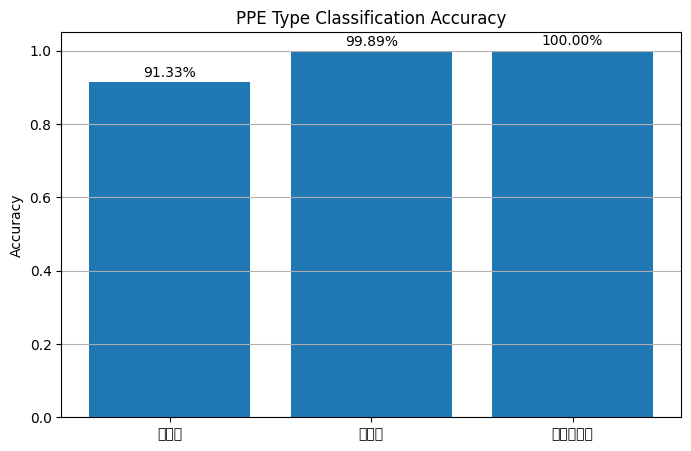

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    ppe_status_summary_df["PPE 종류"],
    ppe_status_summary_df["전체 Accuracy"],
)

plt.ylabel("Accuracy")
plt.title("PPE Type Classification Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y")

for index, value in enumerate(
    ppe_status_summary_df["전체 Accuracy"]
):
    plt.text(
        index,
        value + 0.015,
        f"{value * 100:.2f}%",
        ha="center",
    )

plt.show()

In [15]:
helmet_confusion_df = pd.DataFrame(
    [
        [1433, 1],
        [249, 1200],
    ],
    index=[
        "Actual OFF",
        "Actual ON",
    ],
    columns=[
        "Predicted OFF",
        "Predicted ON",
    ],
)

display(
    helmet_confusion_df
)

,Predicted OFF,Predicted ON
Actual OFF,1433,1
Actual ON,249,1200


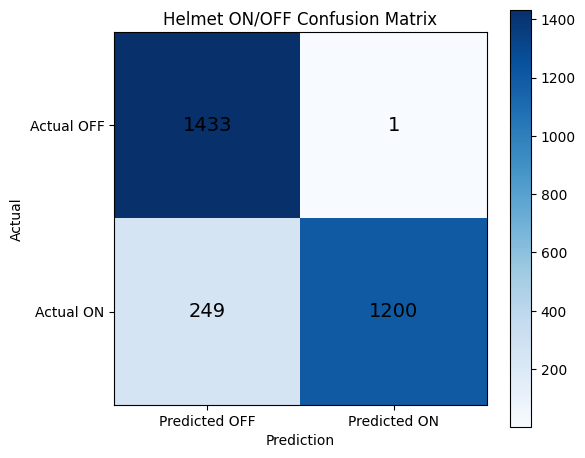

In [16]:
plt.figure(figsize=(6, 5))

plt.imshow(
    helmet_confusion_df.values,
    cmap="Blues",
)

plt.xticks(
    [0, 1],
    helmet_confusion_df.columns,
)

plt.yticks(
    [0, 1],
    helmet_confusion_df.index,
)

plt.title("Helmet ON/OFF Confusion Matrix")
plt.colorbar()

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            helmet_confusion_df.iloc[
                row,
                column,
            ],
            ha="center",
            va="center",
            fontsize=14,
        )

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()